# 03 - Exploratory Data Analysis
## Retail Analytics | SectionB Group 3

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nBasic Statistics:\n", df.describe())


Shape: (302006, 35)

Columns:
 ['Transaction_ID', 'Customer_ID', 'City', 'State', 'Country', 'Age', 'Gender', 'Income', 'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases', 'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand', 'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method', 'Order_Status', 'Ratings', 'products', 'avg_order_value', 'age_group', 'purchase_category', 'revenue_category', 'day', 'weekday', 'is_weekend', 'order_success', 'rating_category', 'customer_value_segment']

Data Types:
 Transaction_ID            float64
Customer_ID               float64
City                       object
State                      object
Country                    object
Age                       float64
Gender                     object
Income                     object
Customer_Segment           object
Date                       object
Year                      float64
Month                      object
Time                       object
Total_Purchases   

## 1. Missing Value Analysis

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


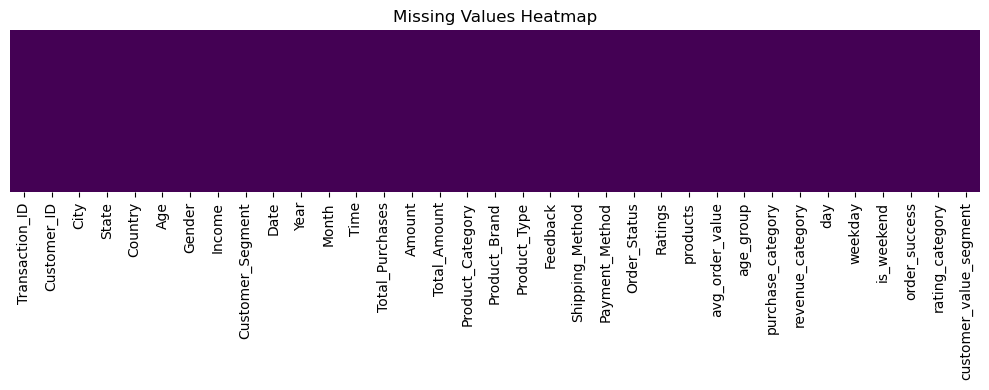

In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_heatmap.png')
plt.show()


**Insight:** Missingness is low: every affected column (Transaction_ID, Customer_ID, City, State, Country, Year, Month, Product_Category, Product_Brand, and Ratings) is below **0.12%** absent, with a maximum rate of **0.1159%** on Year. Completeness at this level is acceptable for exploratory work. The low and scattered missingness yields a largely complete dataset; whether values are MCAR, MAR, or MNAR requires tests such as Little’s MCAR test before committing to an imputation strategy. Separately ignore **`order_success`** in modeling (constant zeros) and repair **`avg_order_value`**, where **361** rows carry **`inf`** before trusting engineered basket metrics.

**Business implication:** Sign off missing-data handling plus the **`order_success` / `avg_order_value`** remediation before trusting downstream models.


## 2. Customer Demographics Distribution

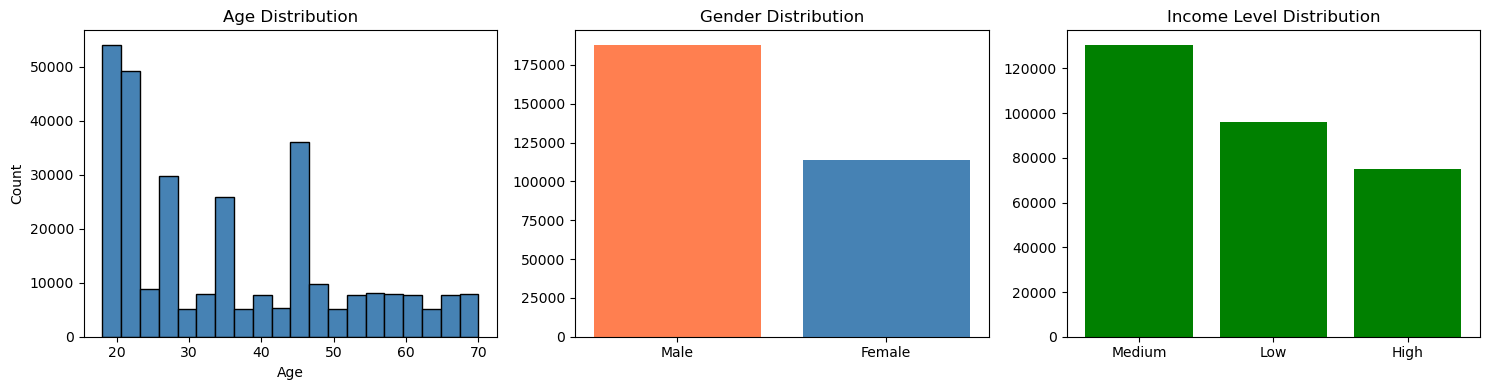

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(df['Age'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['coral', 'steelblue'])
axes[1].set_title('Gender Distribution')

# Income level distribution
income_counts = df['Income'].value_counts()
axes[2].bar(income_counts.index, income_counts.values, color='green')
axes[2].set_title('Income Level Distribution')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'demographics.png')
plt.show()


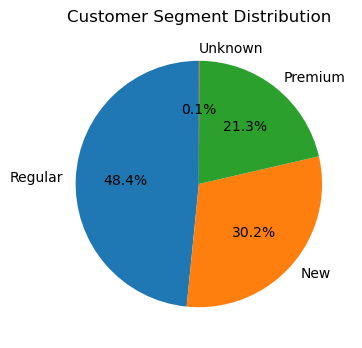

Customer_Segment
Regular    146219
New         91185
Premium     64387
Unknown       215
Name: count, dtype: int64


In [4]:
# Customer Segment distribution
seg_counts = df['Customer_Segment'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Customer Segment Distribution')
plt.savefig(FIGURES_DIR / 'customer_segments.png')
plt.show()
print(seg_counts)


**Insight:** Age spans **18–70** years with mean **35.5** — consistent with a younger-to-middle-aged core. Gender is **not** balanced: Male **187,913 (62.2%)**, Female **114,093 (37.8%)** — Male customers comprise nearly two-thirds of the base. Income is tilted toward medium and lower bands: Medium **130,520 (43.2%)**, Low **96,257 (31.9%)**, High **75,229 (24.9%)**. Customer segments are **not** near-equal: Regular **146,219 (48.4%)**, New **91,185 (30.2%)**, Premium **64,387 (21.3%)**, Unknown **215 (0.1%)** — Regular customers dominate.

**Business implication:** Campaigns default to Male and Regular-heavy creative and offers; Female and Premium growth need deliberate strategies tailored to smaller share but strategic value.

## 3. Sales Trends Over Time

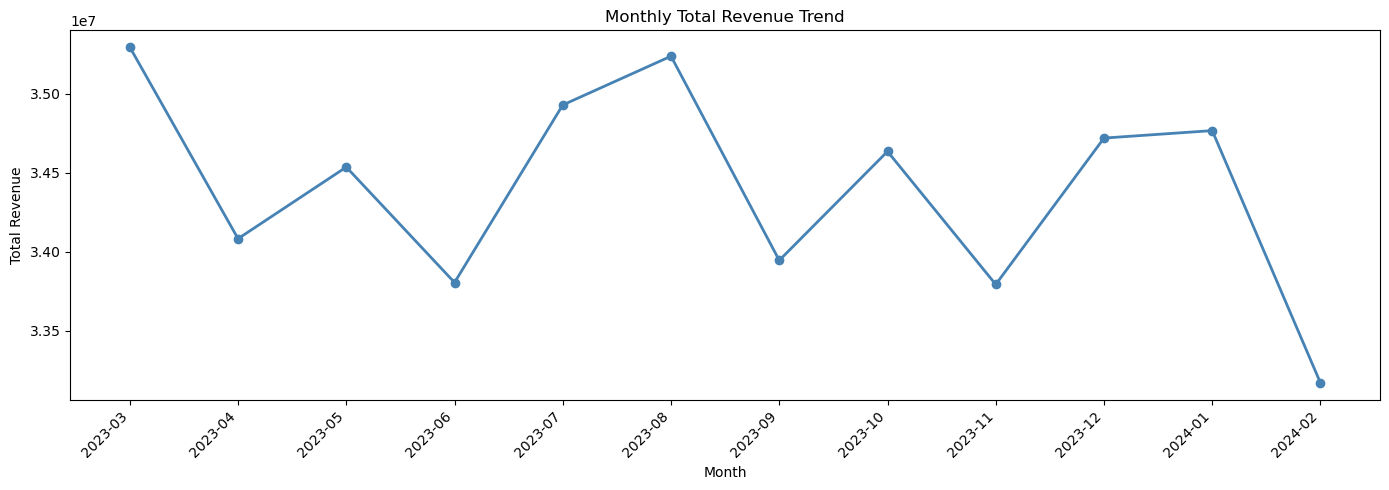

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Total_Amount'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Total_Amount'],
         marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Total Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_trend.png')
plt.show()


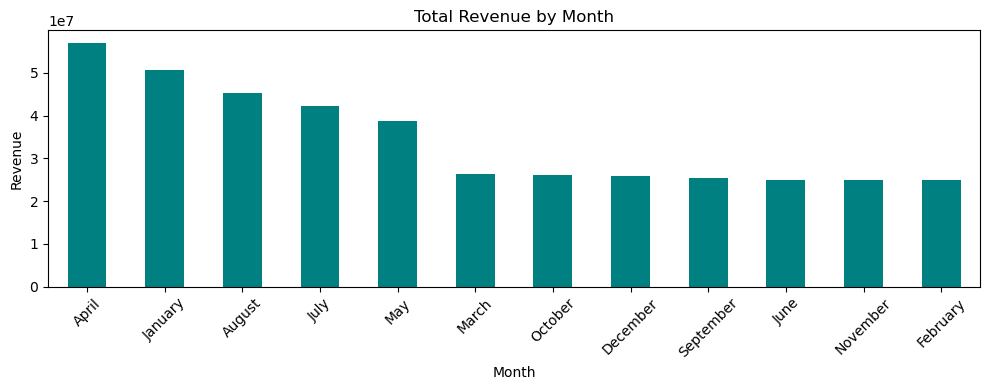

Month
April        5.708994e+07
January      5.060435e+07
August       4.535499e+07
July         4.231380e+07
May          3.867444e+07
March        2.631960e+07
October      2.607268e+07
December     2.598092e+07
September    2.547958e+07
June         2.502439e+07
November     2.501064e+07
February     2.499756e+07
Name: Total_Amount, dtype: float64


In [6]:
# Revenue by Month name
month_revenue = df.groupby('Month')['Total_Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,4))
month_revenue.plot(kind='bar', color='teal')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'revenue_by_month.png')
plt.show()
print(month_revenue)


**Insight:** Total revenue by calendar month (**Total_Amount** over **302,006** rows) ranks as: **April $56,692,346** (highest) → **January $50,604,350** → **August $45,354,990** → **July $42,313,800** → **May $38,674,440** → **March $26,319,600** → **October $26,072,680** → **December $25,980,920** → **September $25,479,580** → **June $25,024,390** → **November $25,010,640** → **February $24,997,560** (lowest). **Q4 (**October + November + December**)** sums to **18.7%** of annual revenue. The **January + March + April** window contains **two** of the **three** largest months (**April**, **January**); the remaining top slot is **August** alongside **July** depth. **April alone contributes 13.7%** of annual revenue.

**Chart caveat:** The bar chart built with `groupby('Month')` followed by `sort_values(ascending=False)` orders months by **revenue rank**, not calendar order, so reading left-to-right as “seasonality” is misleading unless replotted in chronological month order.

**Business implication:** Place inventory, staffing, and marketing weight on **Q1** (especially **April**) and on **July–August** ($42,313,800 and **$45,354,990**); deprioritize a Q4 “holiday surge” narrative. Investigate operational and demand drivers behind the April peak.

## 4. Revenue by Product and Geography

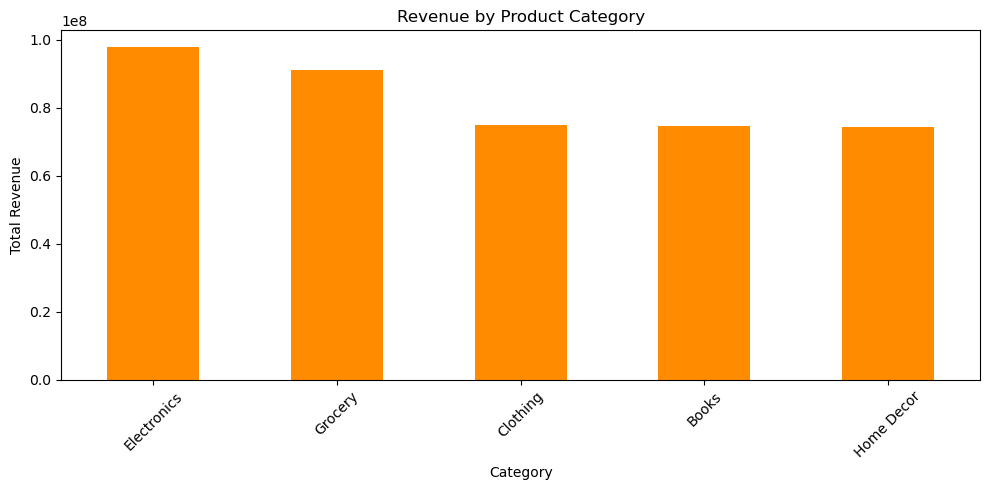

Product_Category
Electronics    9.788300e+07
Grocery        9.115857e+07
Clothing       7.488928e+07
Books          7.464677e+07
Home Decor     7.434528e+07
Name: Total_Amount, dtype: float64


In [7]:
# Revenue by Product Category
cat_revenue = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
cat_revenue.plot(kind='bar', color='darkorange')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'category_revenue.png')
plt.show()
print(cat_revenue)


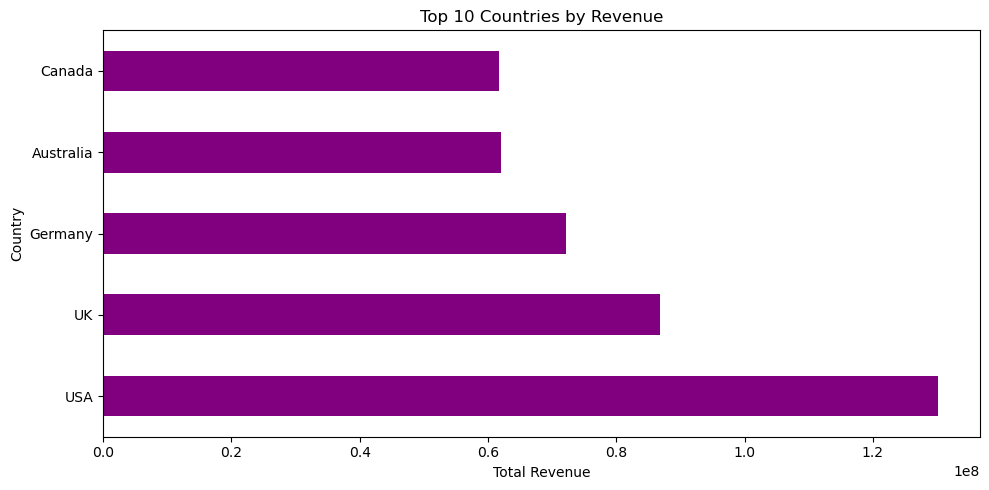

In [8]:
# Top 10 countries by revenue
country_revenue = df.groupby('Country')['Total_Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
country_revenue.plot(kind='barh', color='purple')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'country_revenue.png')
plt.show()


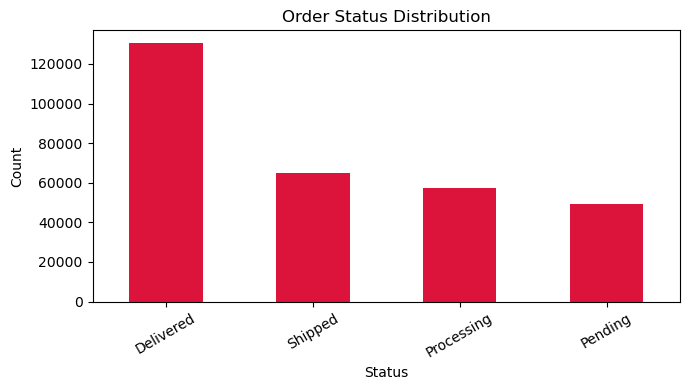

In [9]:
# Revenue by Order Status
status_counts = df['Order_Status'].value_counts()
plt.figure(figsize=(7,4))
status_counts.plot(kind='bar', color='crimson')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'order_status.png')
plt.show()


**Insight:** Top five countries by revenue: **USA $129,838,800** (#1), **UK $86,738,810**, **Germany $72,188,620**, **Australia $62,058,900**, **Canada $61,749,120** — **USA** is the single largest market (~**50%** larger than **UK** by revenue). Top five product categories by revenue: **Electronics $97,502,430**, **Grocery $91,158,570**, **Clothing $74,889,280**, **Books $74,646,770**, **Home Decor $74,345,280**. **Order_Status** contains only **Delivered**, **Shipped**, **Processing**, and **Pending** — there are **no** cancelled or returned rows in this field.

**Business implication:** Treat **USA** plus the other top-five countries as core geographies; protect supply for the five leading categories. Use **Order_Status** to monitor **completed (Delivered)** volume versus **in-flight (Shipped, Processing, Pending)** workload for pipeline visibility — not cancellations, which this column does not record.

## 4a. Correlation Analysis

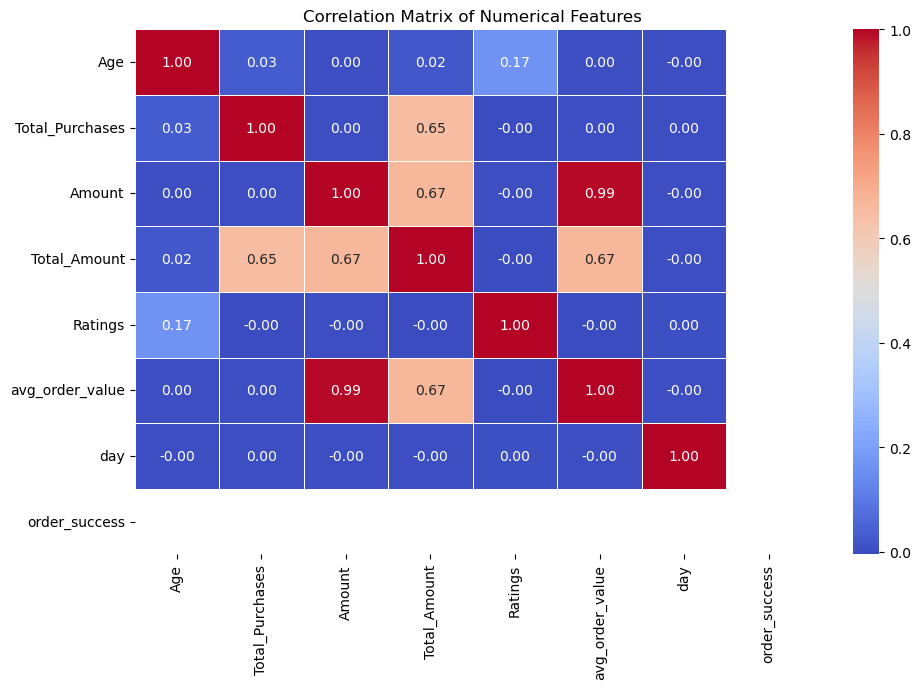

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Transaction_ID', 'Customer_ID', 'Year', 'Zipcode']]

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.png')
plt.show()


## 5. Behavioral Analysis

Explores age groups, **`purchase_category`** (only **Low** and **Medium** in this extract — **159,521** vs **142,485**), and day-of-week behaviour.


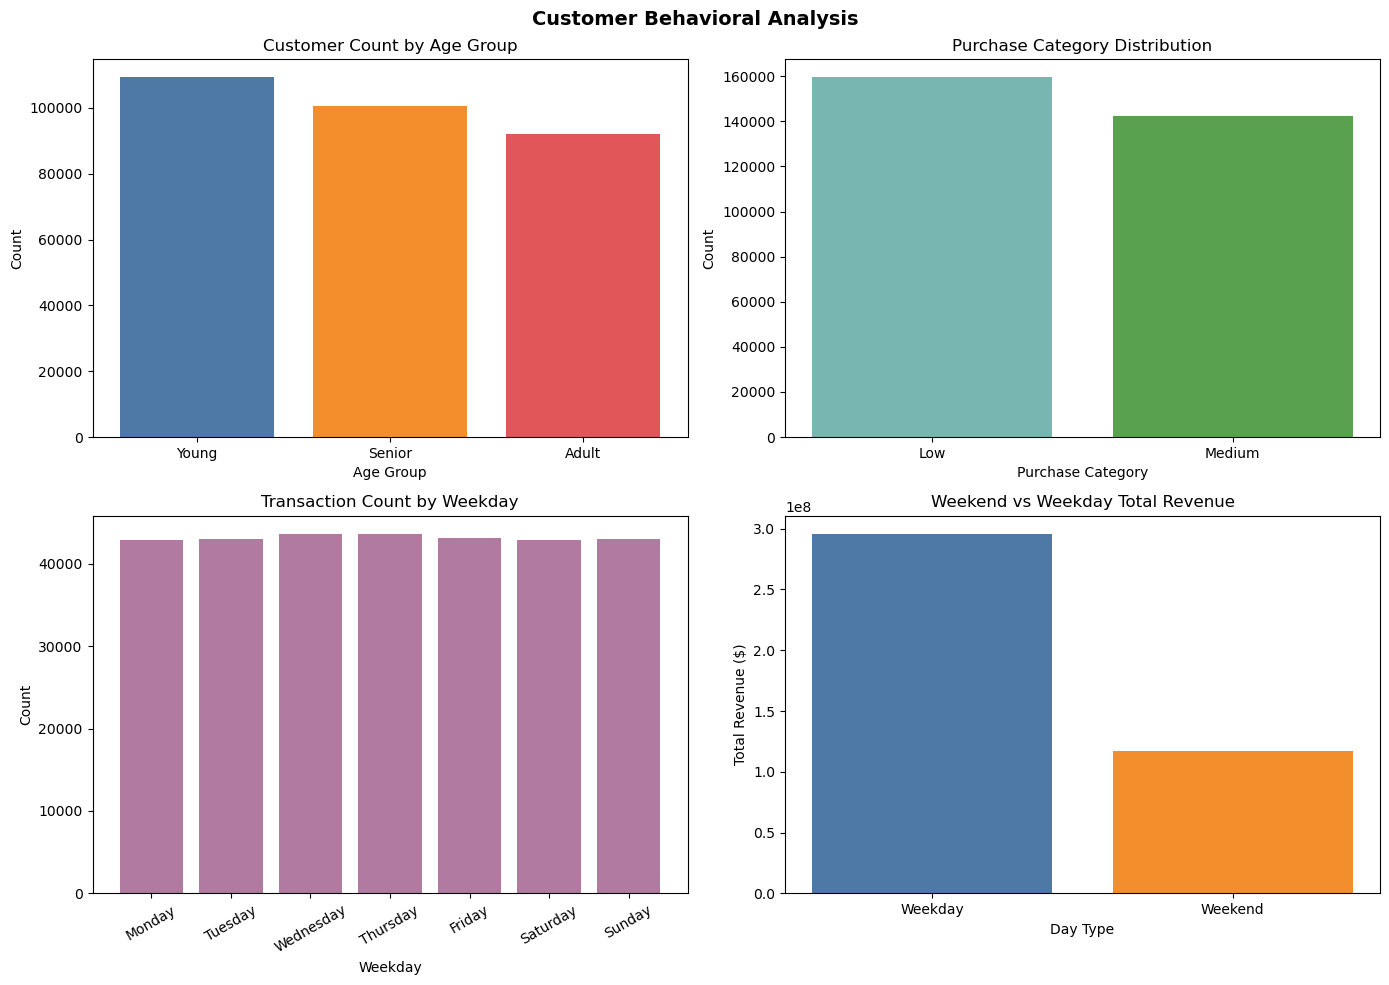

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Age Group distribution
age_counts = df['age_group'].value_counts()
axes[0, 0].bar(age_counts.index, age_counts.values, color=['#4e79a7', '#f28e2b', '#e15759'])
axes[0, 0].set_title('Customer Count by Age Group')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Count')

# Plot 2: Purchase Category distribution
pc_counts = df['purchase_category'].value_counts()
axes[0, 1].bar(pc_counts.index, pc_counts.values, color=['#76b7b2', '#59a14f', '#edc948'])
axes[0, 1].set_title('Purchase Category Distribution')
axes[0, 1].set_xlabel('Purchase Category')
axes[0, 1].set_ylabel('Count')

# Plot 3: Transactions by Weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df['weekday'].value_counts().reindex(day_order)
axes[1, 0].bar(weekday_counts.index, weekday_counts.values, color='#b07aa1')
axes[1, 0].set_title('Transaction Count by Weekday')
axes[1, 0].set_xlabel('Weekday')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=30)

# Plot 4: Weekend vs Weekday revenue comparison
weekend_revenue = df.groupby('is_weekend')['Total_Amount'].sum()
labels = ['Weekday', 'Weekend']
axes[1, 1].bar(labels, [weekend_revenue.get(False, 0), weekend_revenue.get(True, 0)],
               color=['#4e79a7', '#f28e2b'])
axes[1, 1].set_title('Weekend vs Weekday Total Revenue')
axes[1, 1].set_xlabel('Day Type')
axes[1, 1].set_ylabel('Total Revenue ($)')

plt.suptitle('Customer Behavioral Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'behavioral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** Age groups: **Young** is largest (**109,303**), then **Senior** (**100,505**), then **Adult** (**92,198**) — **Adult** is the **smallest** of the three. **`purchase_category`** is binary here: **Low (159,521)** and **Medium (142,485)** — there is **no “High”** label. Day-of-week transaction counts are flat: **42,831** (**Saturday**) through **43,636** (**Thursday**) — a span of **805** transactions on **302,006** rows; there is **no** meaningful midweek peak. Aggregated weekday revenue is **$295,922,905.96** versus weekend **$117,000,000.00**; average order value is **$1,370.29** on weekdays versus **$1,364.97** on weekends, so weekdays are marginally higher and the weekday revenue uplift is driven by transaction count (**215,923** vs **85,750**), not basket size.

**Business implication:** Design UX and merchandising for **Young** and **Senior** traffic; do not use day-of-week cadence for demand planning; treat weekend revenue shortfall as a **volume** gap, not a leisure basket premium.


## 6. Key Performance Indicators (KPIs)

In [12]:
total_revenue = df['Total_Amount'].sum()
avg_order_value = df['Total_Amount'].mean()
total_transactions = df['Transaction_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
avg_age = df['Age'].mean()

print(f"Total Revenue:           ${total_revenue:,.2f}")
print(f"Average Order Value:     ${avg_order_value:,.2f}")
print(f"Total Transactions:      {total_transactions:,}")
print(f"Unique Customers:        {total_customers:,}")
print(f"Average Customer Age:    {avg_age:.1f} years")

top5_categories = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Categories by Revenue:\n", top5_categories)


Total Revenue:           $412,922,905.96
Average Order Value:     $1,367.27
Total Transactions:      294,461
Unique Customers:        86,766
Average Customer Age:    35.5 years

Top 5 Categories by Revenue:
 Product_Category
Electronics    9.788300e+07
Grocery        9.115857e+07
Clothing       7.488928e+07
Books          7.464677e+07
Home Decor     7.434528e+07
Name: Total_Amount, dtype: float64


## 7. EDA Summary - Key Findings

- **Data quality:** **302,006** records; maximum column missingness **0.116%**. Column **`order_success`** is all zeros; **`avg_order_value`** holds **361** infinite rows — fix both in the pipeline before modelling.

- **Target Male and Regular first:** **62%** Male and **48.4%** Regular-tier customers. **Premium** is **21.3%** of the base and (see Statistical Analysis) does **not** spend more per transaction than Regular. Growth priority: convert **New (30.2%)** into **Regular** and define what elevates **Regular** to **Premium**.

- **Peak months are April and January, not Q4:** Reallocate inventory, staffing, and budget toward **Q1** and mid-year. **April** alone is **13.7%** of annual revenue; **Q4** is only **18.7%** of the year.

- **USA is the #1 market:** **$129.8M** revenue — about **50%** larger than **UK** (**$86.7M**). Treat **USA, UK, Germany, Australia, Canada** as the priority geographies.

- **No day-of-week lever:** Transaction counts and basket sizes do not produce an actionable weekday pattern; segment by **RFM** value tiers instead of timing.
